# Preparazione Ambiente e Selezione Categorie

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

# 20 Categorie selezionate
categories = [
    'apple', 'airplane', 'bicycle', 'birthday cake', 'brain',
    'cactus', 'cat', 'coffee cup', 'dolphin', 'eye',
    'fish', 'guitar', 'ice cream', 'octopus', 'owl',
    'palm tree', 'pizza', 'skull', 'snowflake', 't-shirt'
]


IMG_SIZE = 28
N_SAMPLES = 20000
N_CATEGORIES = len(categories)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Numero di categorie impostate: {N_CATEGORIES}")

Numero di categorie impostate: 20


# Collegamento con Drive

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive montato con successo.")
except ImportError:
    print("Google Colab non disponibile: uso una cartella locale.")

Google Colab non disponibile: uso una cartella locale.


# Creazione della cartella per il salvataggio del .pth

In [3]:
import os
from copy import deepcopy

try:
    SAVE_DIR
except NameError:
    SAVE_DIR = os.path.join(os.getcwd(), "quickdraw")

os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(SAVE_DIR, "model.pth")
print("Il modello verrà salvato in:", SAVE_PATH)

Il modello verrà salvato in: c:\Users\MattiaAlbatri\OneDrive - ITS Angelo Rizzoli\Desktop\2025-27.ML---UFS14-main\exam\quickdraw\model.pth


# Caricamento Dati con Barra di Avanzamento

In [4]:
import urllib.request
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

DATA_DIR = Path.cwd() / "quickdraw-dataset-master"
base_url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

def find_local_bitmap(cat):
    file_name = f"{cat.replace(' ', '_')}.npy"
    candidate_dirs = [
        DATA_DIR,
        DATA_DIR / "numpy_bitmap",
        DATA_DIR / "full" / "numpy_bitmap",
        Path.cwd(),
    ]
    for candidate_dir in candidate_dirs:
        candidate_path = candidate_dir / file_name
        if candidate_path.exists():
            return candidate_path
    for candidate_path in DATA_DIR.rglob(file_name):
        return candidate_path
    return None

def download_bitmap(cat, destination_path):
    for variant in [cat.replace(" ", "%20"), cat.replace(" ", "_")]:
        try:
            url = f"{base_url}{variant}.npy"
            urllib.request.urlretrieve(url, destination_path)
            return True
        except Exception:
            continue
    return False

def load_quickdraw_data():
    x, y = [], []
    missing_categories = []

    for idx, cat in enumerate(tqdm.tqdm(categories, desc="Caricamento dataset...")):
        local_path = find_local_bitmap(cat)
        file_name = f"{cat.replace(' ', '_')}.npy"
        if local_path is None:
            local_path = DATA_DIR / file_name
            local_path.parent.mkdir(parents=True, exist_ok=True)
            if not download_bitmap(cat, local_path):
                missing_categories.append(cat)
                continue

        data = np.load(local_path)[:N_SAMPLES]
        x.append(data)
        y.append(np.full(len(data), idx))

    if not x:
        raise FileNotFoundError(
            "Nessun file .npy trovato in quickdraw-dataset-master e download fallito per tutte le categorie."
        )

    if missing_categories:
        print("Categorie non caricate: " + ", ".join(missing_categories))

    x = np.concatenate(x, axis=0) / 255.0
    y = np.concatenate(y, axis=0)
    x = x.reshape(-1, 1, IMG_SIZE, IMG_SIZE).astype(np.float32)
    return x, y.astype(np.int64)

x_data, y_data = load_quickdraw_data()
x_train, x_val, y_train, y_val = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

# Creazione dei DataLoader per gestire i batch
train_dataset = TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train))
val_dataset = TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

Caricamento dataset...: 100%|██████████| 20/20 [02:40<00:00,  8.00s/it]


# Definizione della Rete Convoluzionale (CNN)

In [5]:
class QuickDrawCNN(nn.Module):
    def __init__(self):
        super(QuickDrawCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, N_CATEGORIES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = QuickDrawCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Caricamento del modello per utilizzi futuri

In [6]:
# CARICAMENTO MODELLO
import os

try:
    SAVE_DIR
except NameError:
    SAVE_DIR = os.path.join(os.getcwd(), "quickdraw")

SAVE_PATH = os.path.join(SAVE_DIR, "model.pth")

if os.path.exists(SAVE_PATH):
    print("Checkpoint trovato, analisi dei pesi...")
    checkpoint = torch.load(SAVE_PATH, map_location=device)
    model_dict = model.state_dict()

    # Filtriamo i pesi: carichiamo solo quelli che hanno la stessa forma
    # classifier.4.weight e bias verranno saltati perché la dimensione è diversa
    pretrained_dict = {k: v for k, v in checkpoint.items()
                       if k in model_dict and v.size() == model_dict[k].size()}

    # Applichiamo i pesi filtrati
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)

    print(f"Modello caricato con successo!")
    print(f"Strati caricati correttamente: {len(pretrained_dict)}/{len(model_dict)}")
    if len(pretrained_dict) < len(model_dict):
        print("ATTENZIONE: Alcuni strati (quelli delle categorie) sono stati resettati perché il numero di classi è cambiato da 23 a 20.")
else:
    print("Nessun salvataggio precedente trovato. Il training partirà da zero.")

model.eval()

Nessun salvataggio precedente trovato. Il training partirà da zero.


QuickDrawCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=3136, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=20, bias=True)
  )
)

# Addestramento con Visualizzazione dell'Andamento

Avvio addestramento con Early Stopping...


Epoch 1/20
loss: 1.6766 - accuracy: 0.5139 - val_loss: 1.0817 - val_accuracy: 0.6880
Nuovo best model salvato in c:\Users\MattiaAlbatri\OneDrive - ITS Angelo Rizzoli\Desktop\2025-27.ML---UFS14-main\exam\quickdraw\model.pth


Epoch 2/20
loss: 0.9045 - accuracy: 0.7408 - val_loss: 0.7755 - val_accuracy: 0.7810
Nuovo best model salvato in c:\Users\MattiaAlbatri\OneDrive - ITS Angelo Rizzoli\Desktop\2025-27.ML---UFS14-main\exam\quickdraw\model.pth


Epoch 3/20
loss: 0.7259 - accuracy: 0.7944 - val_loss: 0.6939 - val_accuracy: 0.8030
Nuovo best model salvato in c:\Users\MattiaAlbatri\OneDrive - ITS Angelo Rizzoli\Desktop\2025-27.ML---UFS14-main\exam\quickdraw\model.pth


Epoch 4/20
loss: 0.6338 - accuracy: 0.8160 - val_loss: 0.5872 - val_accuracy: 0.8345
Nuovo best model salvato in c:\Users\MattiaAlbatri\OneDrive - ITS Angelo Rizzoli\Desktop\2025-27.ML---UFS14-main\exam\quickdraw\model.pth


...

Epoch 13/20
loss: 0.2469 - accuracy: 0.9243 - val_loss: 0.5139 - val_accuracy: 0.8620


Epoch 14/20
loss: 0.2300 - accuracy: 0.9245 - val_loss: 0.4857 - val_accuracy: 0.8650


Epoch 15/20
loss: 0.2006 - accuracy: 0.9340 - val_loss: 0.4981 - val_accuracy: 0.8660


Epoch 16/20
loss: 0.1832 - accuracy: 0.9385 - val_loss: 0.5058 - val_accuracy: 0.8655


Epoch 17/20
loss: 0.1682 - accuracy: 0.9442 - val_loss: 0.5117 - val_accuracy: 0.8665
Restoring model weights from the end of the best epoch.
Epoch 17: early stopping


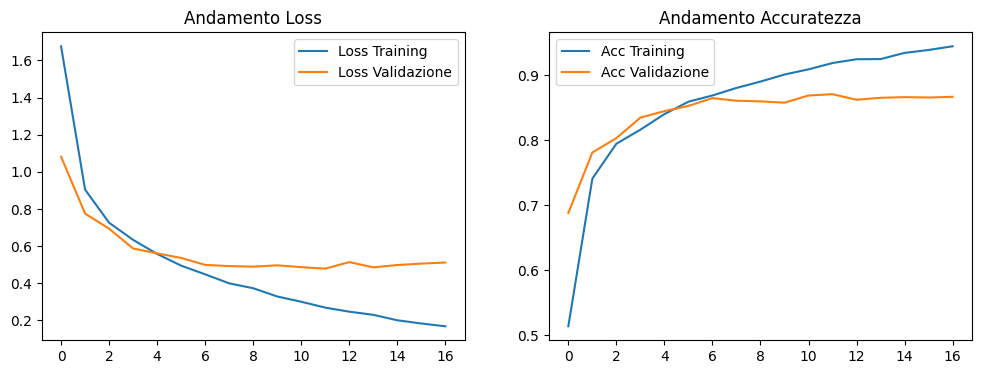

In [7]:
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

max_train_samples = 12000
max_val_samples = 2000

if len(train_dataset) > max_train_samples:
    train_dataset = Subset(train_dataset, range(max_train_samples))
if len(val_dataset) > max_val_samples:
    val_dataset = Subset(val_dataset, range(max_val_samples))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

epochs = 20
patience = 5
best_val_loss = float('inf')
counter = 0
best_model_state = None

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

print("Avvio addestramento con Early Stopping...")

for epoch in range(epochs):
    # Fase di Training
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        train_loader_tqdm.set_postfix(loss=f"{loss.item():.4f}")

    # Fase di Validazione
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # Calcolo metriche
    epoch_train_loss = train_loss / train_total
    epoch_val_loss = val_loss / val_total
    epoch_train_acc = train_correct / train_total
    epoch_val_acc = val_correct / val_total

    history['loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_accuracy'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}")

    # Early Stopping + salvataggio su Drive
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = deepcopy(model.state_dict())
        counter = 0
        torch.save(best_model_state, SAVE_PATH)
        print(f"Nuovo best model salvato in {SAVE_PATH}")
    else:
        counter += 1
        if counter >= patience:
            print("Restoring model weights from the end of the best epoch.")
            print(f"Epoch {epoch+1}: early stopping")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

# Grafici finali
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Loss Training')
plt.plot(history['val_loss'], label='Loss Validazione')
plt.title('Andamento Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Acc Training')
plt.plot(history['val_accuracy'], label='Acc Validazione')
plt.title('Andamento Accuratezza')
plt.legend()

plt.show()

# Salvataggio del modello


In [8]:
if best_model_state is not None:
    torch.save(best_model_state, SAVE_PATH)
    print(f"Modello salvato come {SAVE_PATH}")
else:
    print("Nessun modello da salvare.")

Modello salvato come c:\Users\MattiaAlbatri\OneDrive - ITS Angelo Rizzoli\Desktop\2025-27.ML---UFS14-main\exam\quickdraw\model.pth


# Funzione Predict

In [9]:
import base64
import io
import numpy as np
from PIL import Image
import torch.nn.functional as F

def preprocess_canvas_image(image):
    grayscale = image.convert('L')
    pixels = np.array(grayscale)

    mask = pixels > 20
    if mask.any():
        ys, xs = np.where(mask)
        top, bottom = ys.min(), ys.max() + 1
        left, right = xs.min(), xs.max() + 1
        cropped = grayscale.crop((left, top, right, bottom))

        width, height = cropped.size
        square_size = max(width, height)
        square = Image.new('L', (square_size, square_size), 0)
        square.paste(cropped, ((square_size - width) // 2, (square_size - height) // 2))
        grayscale = square.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
    else:
        grayscale = grayscale.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

    image_array = np.array(grayscale).astype(np.float32) / 255.0
    image_array = (image_array > 0.25).astype(np.float32)

    return torch.from_numpy(image_array).unsqueeze(0).unsqueeze(0).to(device)

def predict_from_image(image):
    image_tensor = preprocess_canvas_image(image)

    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    label = categories[predicted.item()].upper()
    confidence_percent = confidence.item() * 100
    return f"Predizione: {label} (Sicurezza: {confidence_percent:.1f}%)"

def Predict(dataURL):
    header, encoded = dataURL.split(",", 1)
    data = base64.b64decode(encoded)
    image = Image.open(io.BytesIO(data))
    result_text = predict_from_image(image)
    print(result_text)
    return result_text

#UI Interattiva (Canvas)

In [ ]:
from ipywidgets import Button, HBox, HTML as WHTML, Output, VBox
from ipycanvas import Canvas

categories_html = "".join(f"<li>{category.title()}</li>" for category in categories)

card_style = "background: #ffffff; padding: 14px 18px 12px 18px; border-radius: 10px; box-shadow: 0 0 0 1px rgba(0,0,0,0.08); display: inline-block;"
title_style = "margin: 0; font-family: sans-serif; color: #222;"

result_box = WHTML(
    value=(f"<div style='margin-top: 8px; padding-top: 8px; border-top: 1px solid #d0d0d0;'>"
           f"<h3 style='{title_style}'>Disegna qualcosa e premi Predict.</h3></div>")
)
log_box = Output()

canvas = Canvas(width=290, height=290, sync_image_data=True)
canvas.fill_style = "black"
canvas.fill_rect(0, 0, canvas.width, canvas.height)
canvas.stroke_style = "white"
canvas.line_width = 6
canvas.line_cap = "round"

drawing_state = {"active": False, "x": 0, "y": 0}

def reset_canvas():
    canvas.clear()
    canvas.fill_style = "black"
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = "white"
    canvas.line_width = 6
    canvas.line_cap = "round"

def on_mouse_down(x, y):
    drawing_state["active"] = True
    drawing_state["x"] = x
    drawing_state["y"] = y

def on_mouse_move(x, y):
    if not drawing_state["active"]:
        return
    canvas.stroke_line(drawing_state["x"], drawing_state["y"], x, y)
    drawing_state["x"] = x
    drawing_state["y"] = y

def on_mouse_up(x, y):
    drawing_state["active"] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)
canvas.on_mouse_out(on_mouse_up)

predict_btn = Button(description="Predict", button_style="success", layout={"width": "92px"})
clear_btn = Button(description="Clear", button_style="danger", layout={"width": "92px"})

def handle_predict(_):
    image_data = canvas.get_image_data()
    image = Image.fromarray(np.array(image_data).astype(np.uint8), mode="RGBA").convert("L")
    result_text = predict_from_image(image)
    result_box.value = f"<div style='margin-top: 8px; padding-top: 8px; border-top: 1px solid #d0d0d0;'><h3 style='{title_style}'>{result_text}</h3></div>"
    with log_box:
        log_box.clear_output()
        print(result_text)

def handle_clear(_):
    reset_canvas()
    result_box.value = f"<div style='margin-top: 8px; padding-top: 8px; border-top: 1px solid #d0d0d0;'><h3 style='{title_style}'>Disegna qualcosa e premi Predict.</h3></div>"
    with log_box:
        log_box.clear_output()

predict_btn.on_click(handle_predict)
clear_btn.on_click(handle_clear)

categories_box = WHTML(
    value=(f"<div style='margin-top: 10px; font-family: sans-serif;'>"
           f"<h3 style='margin: 0 0 8px 0; color: #111;'>Cosa puoi disegnare:</h3>"
           f"<ul style='margin: 0; padding-left: 22px; line-height: 1.3; color: #222; font-size: 14px;'>"
           f"{categories_html}"
           f"</ul></div>")
)

display(VBox([canvas, HBox([predict_btn, clear_btn]), result_box, categories_box, log_box], layout={"width": "460px"}))